#### Mounting Drive

In [8]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


#### Importing Libraries

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

#### Taking Path

In [10]:
ROOT = "/content/drive/My Drive/Eye Disease/Dataset"

CSV_PATH = os.path.join(ROOT, "full_df.csv")

TRAIN_DIR = os.path.join(ROOT, "ODIR-5K", "ODIR-5K" ,"Training Images")

TEST_DIR = os.path.join(ROOT, "ODIR-5K","ODIR-5K", "Testing Images")

PREPROCESS_DIR = os.path.join(ROOT, "preprocessed_images")

#### Loading Dataset

In [11]:
df = pd.read_csv(CSV_PATH)
df. head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


#### EDA

In [12]:
df.info()
df.describe()

## checking duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())

df.iloc[0]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6392 entries, 0 to 6391
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         6392 non-null   int64 
 1   Patient Age                6392 non-null   int64 
 2   Patient Sex                6392 non-null   object
 3   Left-Fundus                6392 non-null   object
 4   Right-Fundus               6392 non-null   object
 5   Left-Diagnostic Keywords   6392 non-null   object
 6   Right-Diagnostic Keywords  6392 non-null   object
 7   N                          6392 non-null   int64 
 8   D                          6392 non-null   int64 
 9   G                          6392 non-null   int64 
 10  C                          6392 non-null   int64 
 11  A                          6392 non-null   int64 
 12  H                          6392 non-null   int64 
 13  M                          6392 non-null   int64 
 14  O       

,0
ID,0
Patient Age,69
Patient Sex,Female
Left-Fundus,0_left.jpg
Right-Fundus,0_right.jpg
Left-Diagnostic Keywords,cataract
Right-Diagnostic Keywords,normal fundus
N,0
D,0
G,0


##Dataset Summary

In [13]:
print("="*50)
print("Dataset Summary")
print("="*50)

print(f"Total Images: {len(df)}")
print(f"Total Columns: {df.shape[1]}")
print(f"Unique Patients: {df['ID'].nunique()}")

print("\nImage Directory:")
print(TRAIN_DIR)

Dataset Summary
Total Images: 6392
Total Columns: 19
Unique Patients: 3358

Image Directory:
/content/drive/My Drive/Eye Disease/Dataset/ODIR-5K/ODIR-5K/Training Images


##Age Distribution

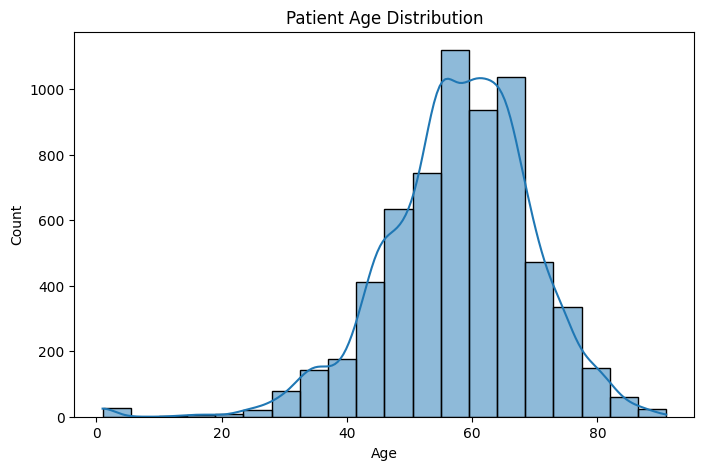

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Patient Age"], bins=20, kde=True)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

##Gebder Distribution

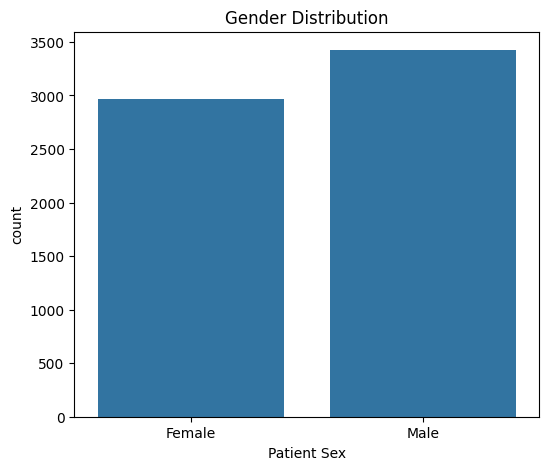

Patient Sex
Male      3424
Female    2968
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Patient Sex")

plt.title("Gender Distribution")

plt.show()

print(df["Patient Sex"].value_counts())

##Disease Distribution

In [16]:
disease_cols = ['N','D','G','C','A','H','M','O']

disease_counts = df[disease_cols].sum().sort_values(ascending=False)

print(disease_counts)

D    2123
N    2101
O    1588
C     402
G     397
A     319
M     306
H     203
dtype: int64


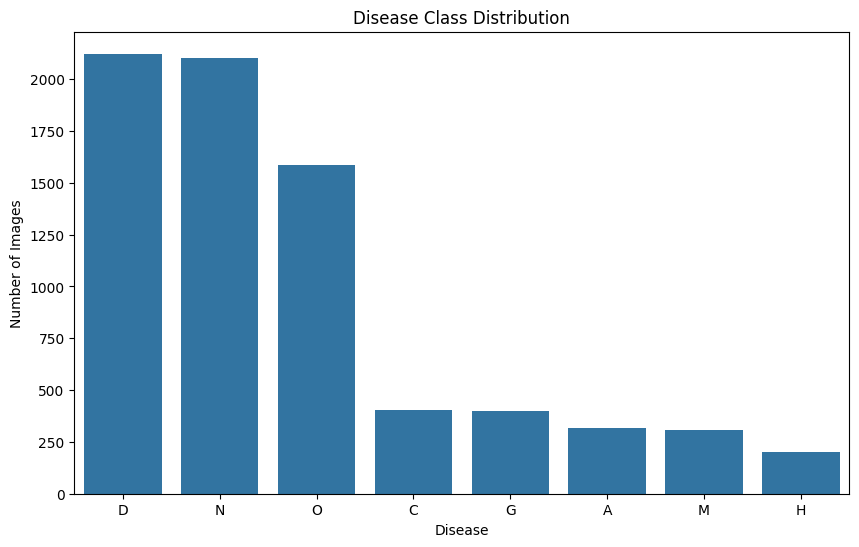

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(x=disease_counts.index,
            y=disease_counts.values)

plt.title("Disease Class Distribution")

plt.xlabel("Disease")

plt.ylabel("Number of Images")

plt.show()

##Disease Percentage

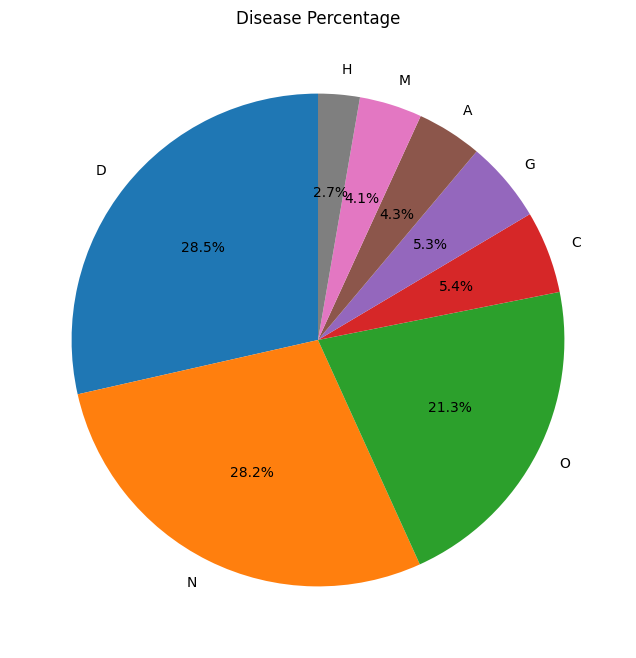

In [18]:
percent = disease_counts / disease_counts.sum() * 100

plt.figure(figsize=(8,8))

plt.pie(percent,
        labels=percent.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Disease Percentage")

plt.show()

##Imbalance Ratio

In [19]:
largest = disease_counts.max()

smallest = disease_counts.min()

print("Largest class :", largest)

print("Smallest class:", smallest)

print("Imbalance Ratio:", round(largest/smallest,2))

Largest class : 2123
Smallest class: 203
Imbalance Ratio: 10.46


##Multi-label Distribution

In [20]:
df["Number_of_Labels"] = df[disease_cols].sum(axis=1)

df["Number_of_Labels"].value_counts()

,count
Number_of_Labels,
1,5391
2,955
3,46


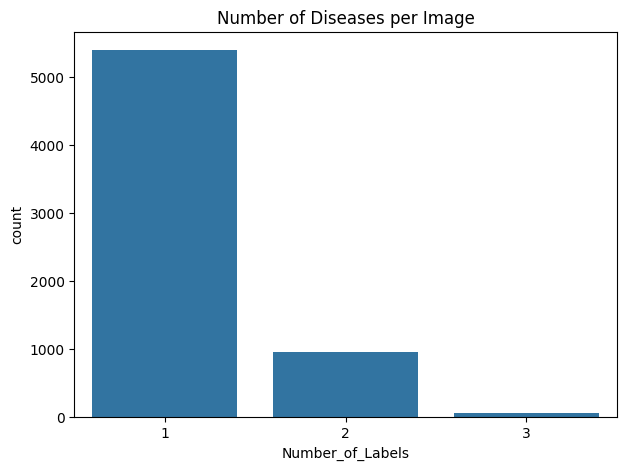

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Number_of_Labels")

plt.title("Number of Diseases per Image")

plt.show()

##Disease Correlation

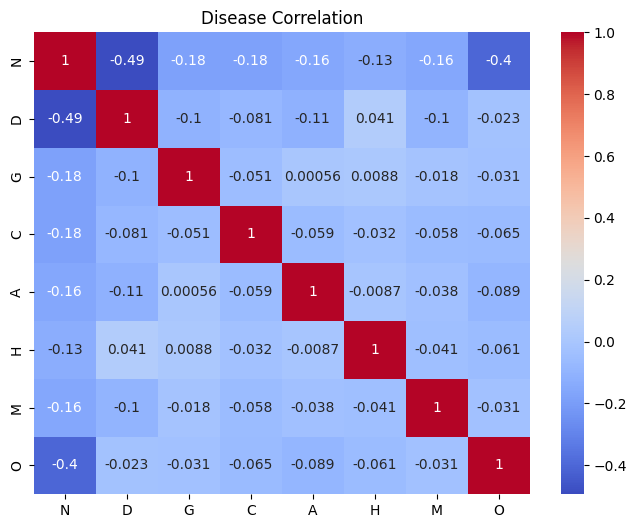

In [22]:
corr = df[disease_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Disease Correlation")

plt.show()

##Age vs Disease

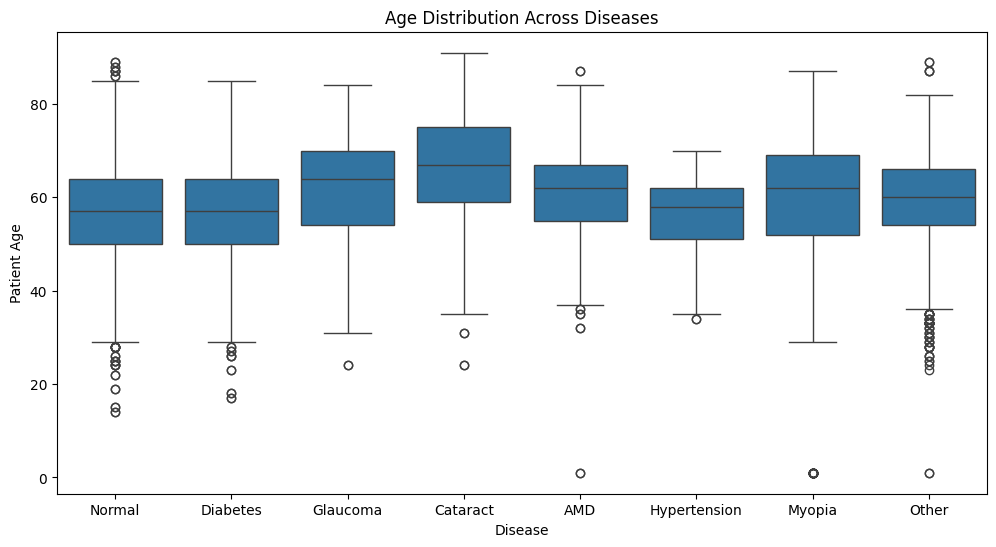

In [23]:
disease_name = {
'N':'Normal',
'D':'Diabetes',
'G':'Glaucoma',
'C':'Cataract',
'A':'AMD',
'H':'Hypertension',
'M':'Myopia',
'O':'Other'
}

long_df = df.melt(
    id_vars=["Patient Age"],
    value_vars=disease_cols,
    var_name="Disease",
    value_name="Present"
)

long_df = long_df[long_df["Present"]==1]

long_df["Disease"] = long_df["Disease"].map(disease_name)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=long_df,
    x="Disease",
    y="Patient Age"
)

plt.title("Age Distribution Across Diseases")

plt.show()

##Gender vs Disease

In [24]:
gender_disease = pd.crosstab(
    df["Patient Sex"],
    df[disease_cols].idxmax(axis=1)
)

gender_disease.columns = [disease_name[i] for i in gender_disease.columns]

gender_disease

,AMD,Cataract,Diabetes,Glaucoma,Hypertension,Myopia,Normal,Other
Patient Sex,,,,,,,,
Female,126,191,940,142,28,176,927,438
Male,141,131,1183,199,59,81,1174,456


##Heatmap

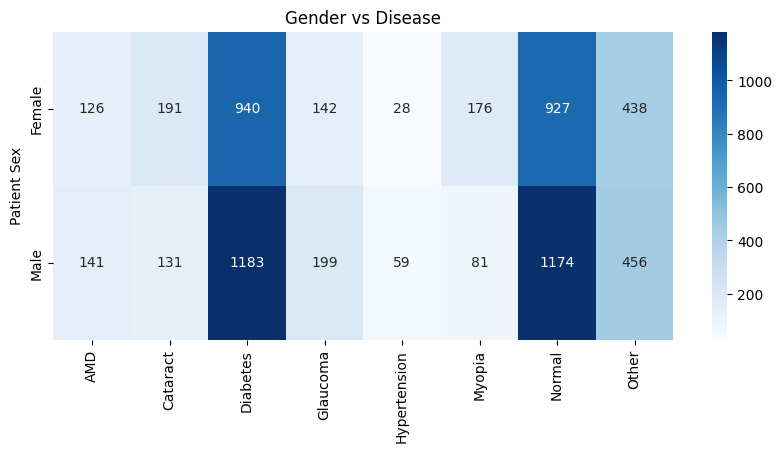

In [25]:
plt.figure(figsize=(10,4))

sns.heatmap(gender_disease,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Gender vs Disease")

plt.show()

##Display Sample Images

In [26]:
import os

image_path = os.path.join(TRAIN_DIR, df.iloc[0]["filename"])

print(image_path)
print(os.path.exists(image_path))

/content/drive/My Drive/Eye Disease/Dataset/ODIR-5K/ODIR-5K/Training Images/0_right.jpg
True


In [27]:
# their is filepath issue so we have apply this
df["filepath"] = df["filename"].apply(
    lambda x: os.path.join(TRAIN_DIR, x)
)

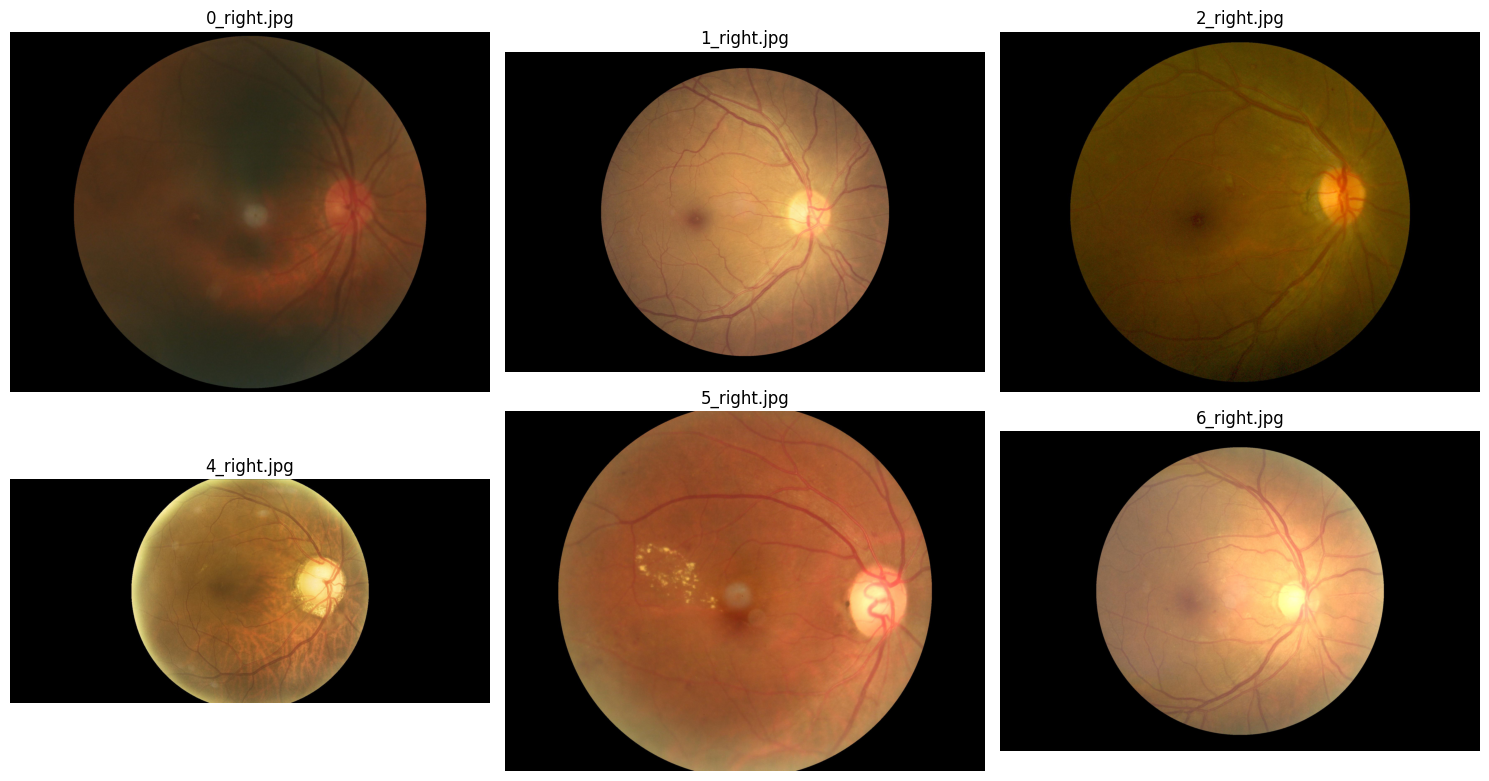

In [28]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

count = 0

for i in range(len(df)):

    img = cv2.imread(df.iloc[i]["filepath"])

    if img is None:
        print("Cannot read:", df.iloc[i]["filepath"])
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,count+1)
    plt.imshow(img)
    plt.title(df.iloc[i]["filename"])
    plt.axis("off")

    count += 1

    if count == 6:
        break

plt.tight_layout()
plt.show()

##Image Resolution Analysis

In [29]:
import cv2
from tqdm import tqdm

widths = []
heights = []

for path in tqdm(df["filepath"]):
    img = cv2.imread(path)

    if img is None:
        continue

    h, w = img.shape[:2]

    widths.append(w)
    heights.append(h)

  7%|▋         | 477/6392 [04:10<51:49,  1.90it/s]


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(widths, heights, alpha=0.4)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Resolution Distribution")

plt.show()

##Brightness Distribution

In [ ]:
import cv2

brightness = []

for path in df["filepath"]:

    img = cv2.imread(path)

    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness.append(gray.mean())

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(brightness,
             bins=30,
             kde=True)

plt.title("Brightness Distribution")

plt.xlabel("Average Brightness")

plt.show()

##Plot Intensity Histogram

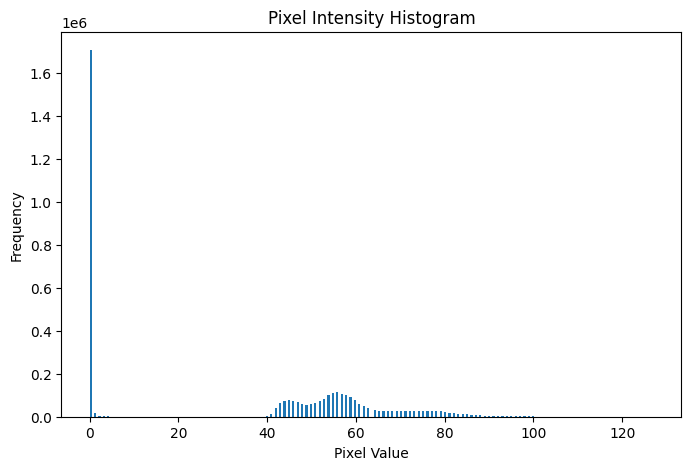

In [30]:
img = cv2.imread(df.iloc[0]["filepath"])

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,5))

plt.hist(gray.ravel(),
         bins=256)

plt.title("Pixel Intensity Histogram")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

##Sample image for each disease

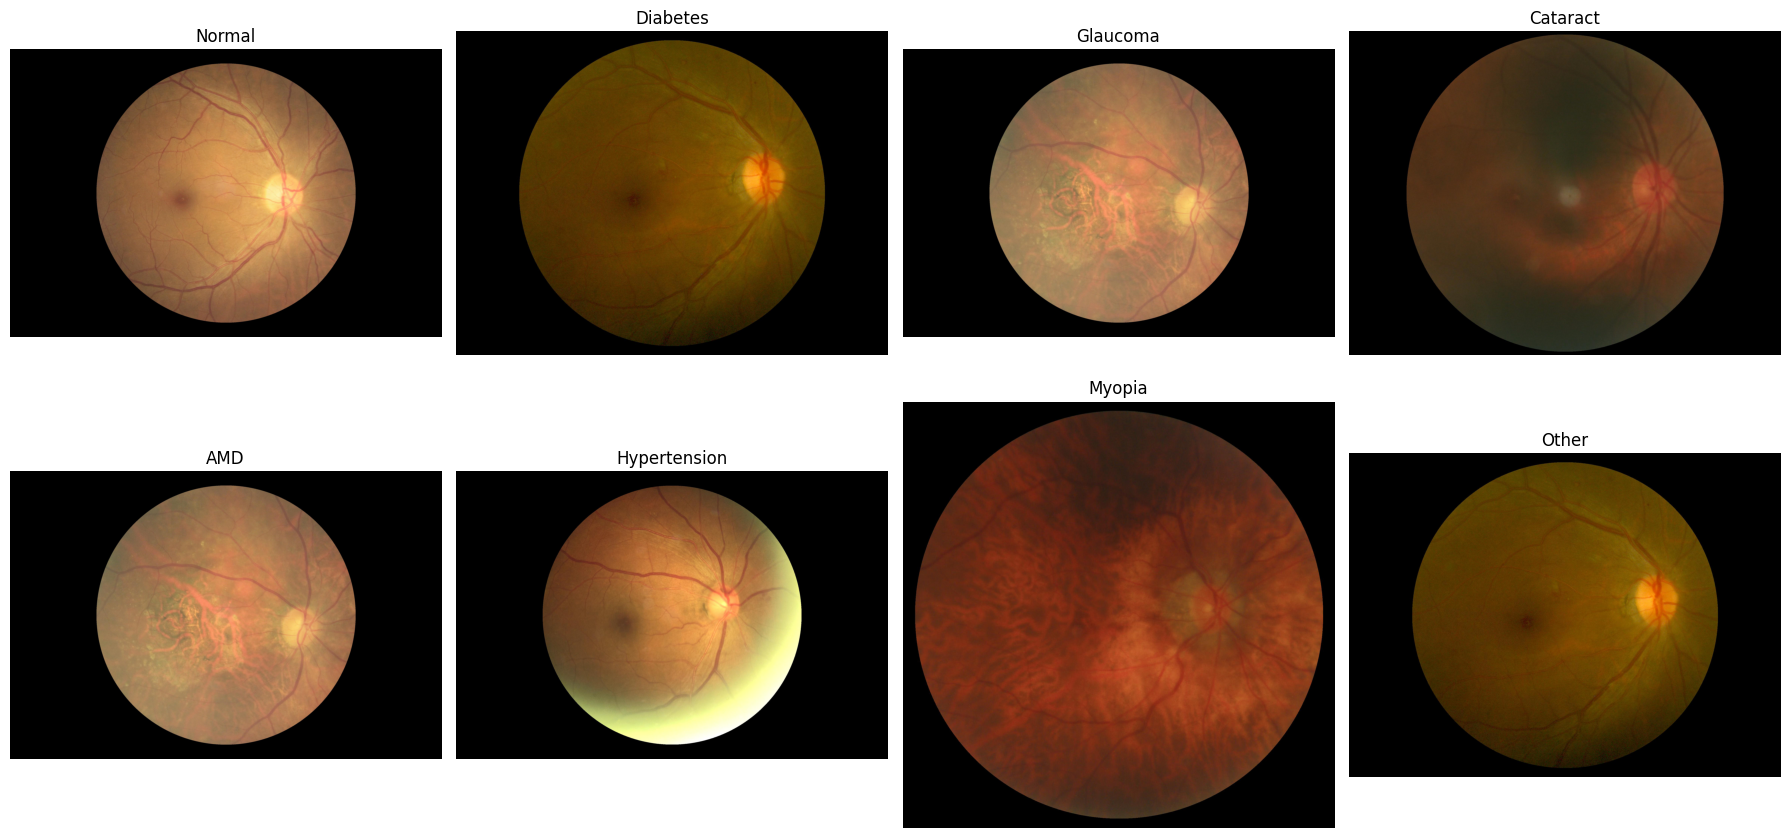

In [31]:
disease_name = {
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
}

fig, axes = plt.subplots(2,4, figsize=(18,9))

axes = axes.flatten()

for i, col in enumerate(disease_name.keys()):

    sample = df[df[col] == 1].iloc[0]

    img = cv2.imread(sample["filepath"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(disease_name[col], fontsize=12)
    axes[i].axis("off")

plt.tight_layout()

plt.show()

**The original Training Images directory contained 7000 images. However, only the 6392 images referenced in full_df.csv were used for analysis and model development, as these images have complete metadata and disease labels.**

In [32]:
train_images = df["filename"].tolist()

print("Total labeled images:", len(train_images))

Total labeled images: 6392


##Image counting in each folders

In [33]:
import os

train_images = os.listdir(TRAIN_DIR)
test_images = os.listdir(TEST_DIR)
preprocess_images = os.listdir(PREPROCESS_DIR)

print("Training Images :", len(train_images))
print("Testing Images  :", len(test_images))
print("Preprocessed Images :", len(preprocess_images))

Training Images : 7000
Testing Images  : 1000
Preprocessed Images : 6392


##Check Missing Images

In [34]:
missing = []

for file in train_images:

    path = os.path.join(TRAIN_DIR, file)

    if not os.path.exists(path):
        missing.append(file)

print("Missing Images:", len(missing))

Missing Images: 0


##Corrupted Images

In [ ]:
import cv2
from tqdm import tqdm

corrupted = []

for file in tqdm(train_images):

    img = cv2.imread(os.path.join(TRAIN_DIR, file))

    if img is None:
        corrupted.append(file)

print("Corrupted Images:", len(corrupted))

##Resolution Analysis

In [35]:
widths = []
heights = []

for file in tqdm(train_images):

    img = cv2.imread(os.path.join(TRAIN_DIR, file))

    if img is None:
        continue

    h, w = img.shape[:2]

    widths.append(w)
    heights.append(h)

resolution_df = pd.DataFrame({
    "Width": widths,
    "Height": heights
})

resolution_df.describe()

  0%|          | 4/7000 [00:02<1:08:48,  1.69it/s]


KeyboardInterrupt: 

##Unique Resolutions

In [37]:
resolution_df["Resolution"] = (
    resolution_df["Width"].astype(str)
    + " × "
    + resolution_df["Height"].astype(str)
)

resolution_df["Resolution"].value_counts()

NameError: name 'resolution_df' is not defined

##Brightness Distribution

In [ ]:
brightness = []

for file in tqdm(train_images[:500]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file), 0)

    brightness.append(img.mean())

plt.figure(figsize=(8,5))

sns.histplot(brightness, bins=30, kde=True)

plt.title("Brightness Distribution")
plt.show()

##Contrast Distribution

In [ ]:
contrast = []

for file in tqdm(train_images[:500]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file), 0)

    contrast.append(img.std())

plt.figure(figsize=(8,5))

plt.hist(contrast, bins=30)

plt.title("Contrast Distribution")

plt.show()

##Sharpness Distribution

In [ ]:
def laplacian_variance(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()

sharpness = []

for file in tqdm(train_images[:500]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file), 0)

    sharpness.append(laplacian_variance(img))

plt.figure(figsize=(8,5))

plt.hist(sharpness, bins=30)

plt.title("Sharpness Distribution")

plt.show()

##RGB Channel Statistics

In [ ]:
rgb_mean = []

for file in tqdm(train_images[:300]):

    img = cv2.imread(os.path.join(TRAIN_DIR, file))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    rgb_mean.append(img.mean(axis=(0,1)))

rgb_mean = np.array(rgb_mean)

plt.figure(figsize=(10,5))

plt.plot(rgb_mean[:,0], label="Red")
plt.plot(rgb_mean[:,1], label="Green")
plt.plot(rgb_mean[:,2], label="Blue")

plt.legend()

plt.title("RGB Channel Means")

plt.show()

##Display Original vs Preprocessed

In [ ]:
train_set = set(os.listdir(TRAIN_DIR))
prep_set = set(os.listdir(PREPROCESS_DIR))

common = train_set & prep_set
missing = train_set - prep_set
extra = prep_set - train_set

print("Training images:", len(train_set))
print("Preprocessed images:", len(prep_set))
print("Matching filenames:", len(common))
print("Missing from preprocessing:", len(missing))
print("Extra files:", len(extra))

print("\nFirst 10 missing:")
print(list(missing)[:10])

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

common_files = sorted(
    list(set(os.listdir(TRAIN_DIR)) & set(os.listdir(PREPROCESS_DIR)))
)

print("Common files:", len(common_files))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for i, file in enumerate(common_files[:3]):

    original = cv2.imread(os.path.join(TRAIN_DIR, file))
    processed = cv2.imread(os.path.join(PREPROCESS_DIR, file))

    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    processed = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)

    ax[0, i].imshow(original)
    ax[0, i].set_title("Original")
    ax[0, i].axis("off")

    ax[1, i].imshow(processed)
    ax[1, i].set_title("Preprocessed")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()

##Disease-wise Gallery(displaying 3 images from each disease classes)

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

# Disease labels
disease_map = {
    'N': 'Normal',
    'D': 'Diabetes',
    'G': 'Glaucoma',
    'C': 'Cataract',
    'A': 'AMD',
    'H': 'Hypertension',
    'M': 'Myopia',
    'O': 'Other'
}

fig, axes = plt.subplots(8, 3, figsize=(12, 28))

for row, (col, disease_name) in enumerate(disease_map.items()):

    # Get all images belonging to this disease
    disease_samples = df[df[col] == 1]["filename"].head(3).tolist()

    for col_idx in range(3):

        ax = axes[row, col_idx]

        if col_idx < len(disease_samples):

            file = disease_samples[col_idx]
            img_path = os.path.join(TRAIN_DIR, file)

            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
            else:
                ax.text(0.2, 0.5, "Image Not Found", fontsize=10)

        else:
            ax.text(0.2, 0.5, "No Image", fontsize=10)

        if col_idx == 0:
            ax.set_ylabel(disease_name, fontsize=13, rotation=90, labelpad=20)

        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Disease-wise Image Gallery (3 Images per Class)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [38]:
import os

print(len(os.listdir(TEST_DIR)))
print(sorted(os.listdir(TEST_DIR))[:10])

1000
['1000_left.jpg', '1000_right.jpg', '1001_left.jpg', '1001_right.jpg', '1002_left.jpg', '1002_right.jpg', '1003_left.jpg', '1003_right.jpg', '1004_left.jpg', '1004_right.jpg']


In [39]:
test_files = set(os.listdir(TEST_DIR))
csv_files = set(df["filename"])

print("Common files:", len(test_files & csv_files))

Common files: 0


In [40]:
import pandas as pd
import os

DATA_PATH = os.path.join(ROOT,"ODIR-5K","ODIR-5K", "data.xlsx")

data_df = pd.read_excel(DATA_PATH)

print(data_df.shape)
data_df.head()

(3500, 15)


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1
3,3,66,Male,3_left.jpg,3_right.jpg,normal fundus,branch retinal artery occlusion,0,0,0,0,0,0,0,1
4,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1


In [41]:
data_df[data_df["ID"] == 1000]

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O


In [42]:
data_df[(data_df["ID"] >= 1000) & (data_df["ID"] <= 1499)]

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
994,1005,78,Female,1005_left.jpg,1005_right.jpg,macular hole,normal fundus,0,0,0,0,0,0,0,1
995,1006,64,Male,1006_left.jpg,1006_right.jpg,normal fundus,macular epiretinal membrane,0,0,0,0,0,0,0,1
996,1008,65,Male,1008_left.jpg,1008_right.jpg,normal fundus,epiretinal membrane,0,0,0,0,0,0,0,1
997,1010,63,Female,1010_left.jpg,1010_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
998,1011,36,Male,1011_left.jpg,1011_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,1494,38,Male,1494_left.jpg,1494_right.jpg,glaucoma,normal fundus,0,0,1,0,0,0,0,0
1333,1495,64,Female,1495_left.jpg,1495_right.jpg,glaucoma,glaucoma,0,0,1,0,0,0,0,0
1334,1496,31,Female,1496_left.jpg,1496_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy，glaucoma,0,1,1,0,0,0,0,0
1335,1497,54,Male,1497_left.jpg,1497_right.jpg,glaucoma,glaucoma,0,0,1,0,0,0,0,0


In [43]:
test_records = data_df[(data_df["ID"] >= 1000) & (data_df["ID"] <= 1499)]

print("Rows found:", len(test_records))
test_records.head(10)

Rows found: 343


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O
994,1005,78,Female,1005_left.jpg,1005_right.jpg,macular hole,normal fundus,0,0,0,0,0,0,0,1
995,1006,64,Male,1006_left.jpg,1006_right.jpg,normal fundus,macular epiretinal membrane,0,0,0,0,0,0,0,1
996,1008,65,Male,1008_left.jpg,1008_right.jpg,normal fundus,epiretinal membrane,0,0,0,0,0,0,0,1
997,1010,63,Female,1010_left.jpg,1010_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
998,1011,36,Male,1011_left.jpg,1011_right.jpg,normal fundus,drusen,0,0,0,0,0,0,0,1
999,1012,56,Female,1012_left.jpg,1012_right.jpg,drusen,pathological myopia,0,0,0,0,0,0,1,1
1000,1013,66,Female,1013_left.jpg,1013_right.jpg,normal fundus,macular epiretinal membrane，drusen,0,0,0,0,0,0,0,1
1001,1014,70,Female,1014_left.jpg,1014_right.jpg,retinal pigmentation,normal fundus,0,0,0,0,0,0,0,1
1002,1015,53,Female,1015_left.jpg,1015_right.jpg,drusen,drusen,0,0,0,0,0,0,0,1
1003,1016,62,Female,1016_left.jpg,1016_right.jpg,normal fundus,epiretinal membrane,0,0,0,0,0,0,0,1


In [44]:
test_filenames = os.listdir(TEST_DIR)

left_matches = data_df[data_df["Left-Fundus"].isin(test_filenames)]
right_matches = data_df[data_df["Right-Fundus"].isin(test_filenames)]

print("Left matches :", len(left_matches))
print("Right matches:", len(right_matches))

Left matches : 0
Right matches: 0


##Splitting Dataset (70/15/15)

In [45]:
# Create a Single Label Column
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

df['label'] = df[label_cols].idxmax(axis=1)

df[['filename', 'label']].head()

,filename,label
0,0_right.jpg,C
1,1_right.jpg,N
2,2_right.jpg,D
3,4_right.jpg,D
4,5_right.jpg,D


In [46]:
print(df['label'].value_counts())

label
D    2123
N    2101
O     894
G     341
C     322
A     267
M     257
H      87
Name: count, dtype: int64


##First Split (70% Train, 30% Temporary)

In [47]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['label']
)

print("Training images :", len(train_df))
print("Temporary images:", len(temp_df))

Training images : 4474
Temporary images: 1918


In [48]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))

Training   : 4474
Validation : 959
Testing    : 959


##Verifying Percentages

In [49]:
total = len(df)

print(f"Train      : {len(train_df)} ({len(train_df)/total:.1%})")
print(f"Validation : {len(val_df)/total:.1%})")
print(f"Test       : {len(test_df)/total:.1%})")

Train      : 4474 (70.0%)
Validation : 15.0%)
Test       : 15.0%)


##Check Class Distribution

In [50]:
print("Original Dataset")
print(df['label'].value_counts(normalize=True).sort_index())

print("\nTraining")
print(train_df['label'].value_counts(normalize=True).sort_index())

print("\nValidation")
print(val_df['label'].value_counts(normalize=True).sort_index())

print("\nTesting")
print(test_df['label'].value_counts(normalize=True).sort_index())

Original Dataset
label
A    0.041771
C    0.050375
D    0.332134
G    0.053348
H    0.013611
M    0.040207
N    0.328692
O    0.139862
Name: proportion, dtype: float64

Training
label
A    0.041797
C    0.050291
D    0.332141
G    0.053420
H    0.013634
M    0.040232
N    0.328565
O    0.139920
Name: proportion, dtype: float64

Validation
label
A    0.041710
C    0.050052
D    0.332638
G    0.053180
H    0.013556
M    0.039625
N    0.329510
O    0.139729
Name: proportion, dtype: float64

Testing
label
A    0.041710
C    0.051095
D    0.331595
G    0.053180
H    0.013556
M    0.040667
N    0.328467
O    0.139729
Name: proportion, dtype: float64


##Visualize the Distribution

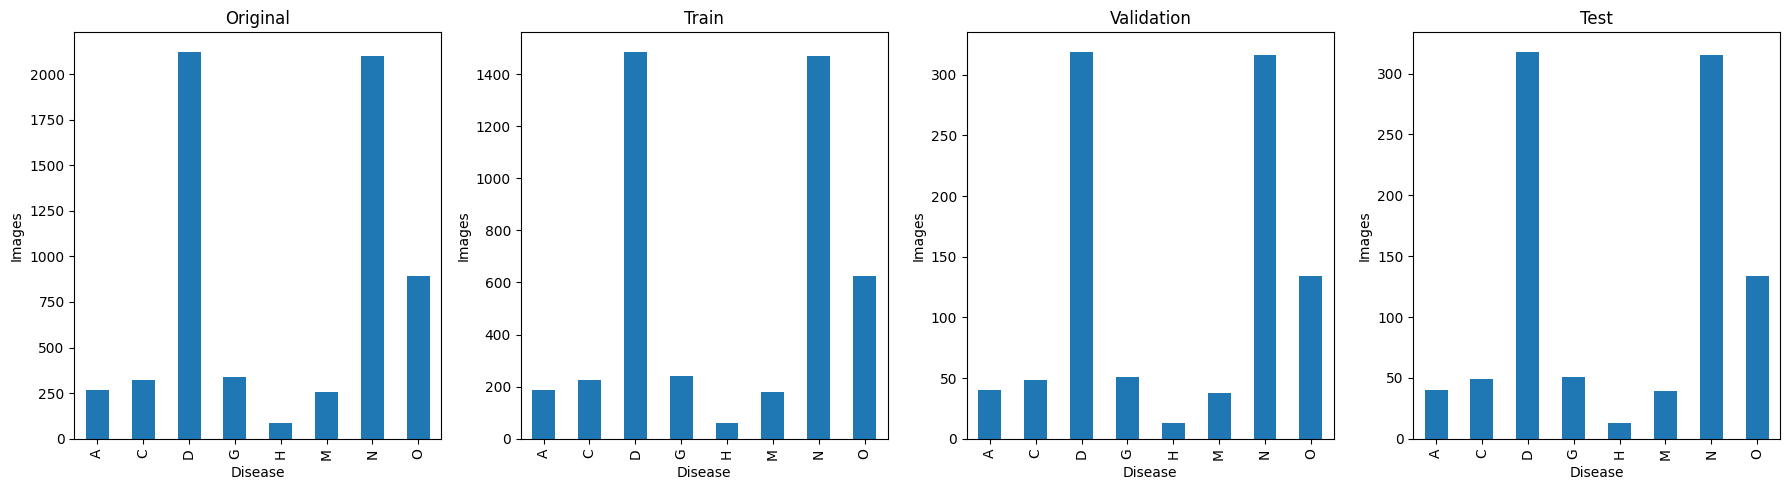

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18,5))

df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Original')
train_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Train')
val_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Validation')
test_df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[3], title='Test')

for ax in axes:
    ax.set_xlabel("Disease")
    ax.set_ylabel("Images")

plt.tight_layout()
plt.show()